In [1]:
using Pkg
using Metal

cd(@__DIR__)
Pkg.activate("../")
ParamFile = "../config/testparam.csv"  # maybe GeoPoints and planet1D should be fusioned

# batchGPU should be at this level (I have not made it as a module yet, since the choice of Metal/CUDA should be done in a manual way)
include("../src/batchFiles/batchGPU.jl")


include("../src/commonBatchs.jl")
include("../src/planet1D.jl")
include("../src/GeoPoints.jl")

include("../src/flexOPT.jl")

using .commonBatchs, .planet1D, .GeoPoints, .flexOPT

  Activating project at `~/Documents/Github/flexOPT`


devs = Metal.devices() = Metal.MTL.MTLDeviceInstance[Metal.MTL.MTLDeviceInstance (object of type AGXG13XDevice)]
→ Using Metal backend (1 device(s))
Selected backend type: MetalBackend


# model construction

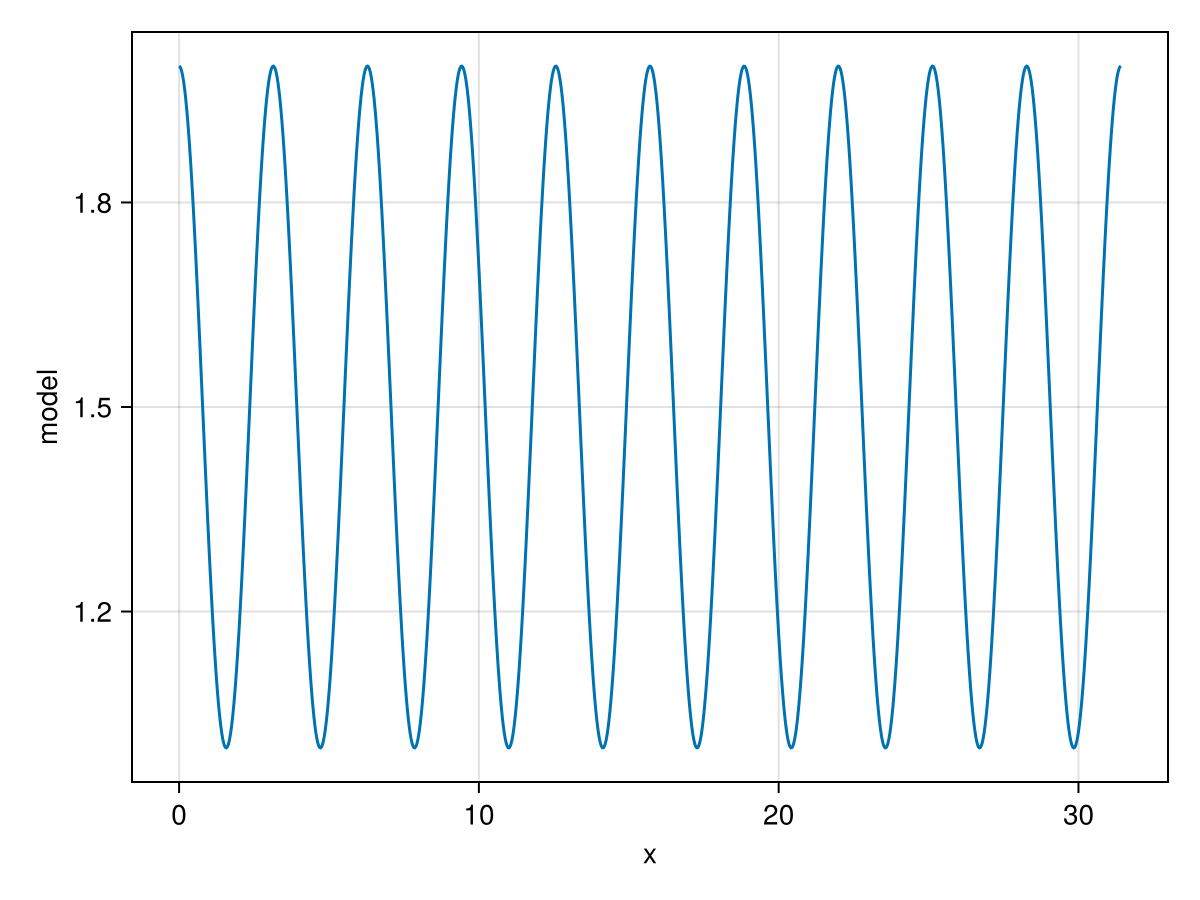

In [2]:
using Symbolics,CairoMakie
numPointsX = collect(2:2)
logsOfHinverse = [1.0*i for i in 0:3]

cases=[]
#prefix="B"*string(tmpOrderBspace)*"_"*"w"*string(tmpWorderBspace)*"_"*string(tmpSupplementaryOrder)*"_"
prefix=""
L = 10.0*π
cases = push!(cases,(name=prefix*"λ_2",u=cos(x),β=cos(x).^2 + 1))

@variables x
∂ = Differential(x)


misfit = Array{Float64,3}(undef,length(logsOfHinverse),length(cases),length(numPointsX))

modelFamily=[]

fig = Figure()
ax = Axis(fig[1, 1], xlabel="x", ylabel="model")
Nx=1000
Δx=L/(Nx-1)
X = [Δx * (i-1) for i ∈ range(1,Nx)]

for iCase ∈ eachindex(cases)
    name,_,β = cases[iCase]
    models=[]
    model=[Symbolics.value(substitute(β,Dict(x=>X[i]))) for i ∈ range(1,Nx)]
    models=push!(models, model)

    for iH ∈ eachindex(logsOfHinverse)
        modelName = name*string(Nx)
        ΔxTry = exp(-logsOfHinverse[iH])
        Nx = Int(L÷ΔxTry) +1
        Δx = L/(Nx-1)
        modelPoints = (Nx)
        tmpModel = (models=models, modelName=modelName, modelPoints=modelPoints)
        modelFamily=push!(modelFamily,tmpModel)
    end

    lines!(ax, X, models[end])
end
display(fig)
for iPointsUsed ∈ eachindex(numPointsX), iCase ∈ eachindex(cases), iH ∈ eachindex(logsOfHinverse)
    name,u,β = cases[iCase]
    
    models=modelFamily[iCase]
    q = mySimplify(β*∂(u))
    qₓ = mySimplify(∂(q))
    
    iExperiment = (iH=iH,iCase=iCase,iPointsUsed=iPointsUsed)
    
    force = [Symbolics.value(substitute(qₓ,Dict(x=>X[i]))) for i ∈ range(1,Nx)]
    

    

    
end


# input parameters

In [3]:

famousEquationType="1DpoissonHetero" #GT98
Δ = (1.0)

1.0

In [4]:


# orders: -1 -> indicator function, 0 -> box car, >=1 -> B-spline

orderBtime=1
orderBspace=1

pointsInSpace=3
pointsInTime=3

# the order of errors to be controlled
supplementaryOrder=2

# new parameters for interpolated Taylor expansion μ for field

fieldItpl = (ptsSpace = 1,ptsTime = 1,offsetSpace=1,offsetTime=1,YorderBspace=1,YorderBtime=1) #offsetSpace and offsetTime ∈ z 
# μ points should be distributed from y_min+offset*Δy to y_max-offset*Δy offset can be negative too


# new parameters for interpolated Taylor expansion μᶜ for material
materItpl = (ptsSpace = 1,ptsTime = 1,offsetSpace=1,offsetTime=1,YorderBspace=1,YorderBtime=1)



(ptsSpace = 1, ptsTime = 1, offsetSpace = 1, offsetTime = 1, YorderBspace = 1, YorderBtime = 1)

In [5]:
concreteParametersForOPTConstruction = @strdict famousEquationType Δ orderBtime orderBspace pointsInSpace pointsInTime supplementaryOrder fieldItpl materItpl


Dict{String, Any} with 9 entries:
  "fieldItpl"          => (ptsSpace = 1, ptsTime = 1, offsetSpace = 1, offsetTi…
  "Δ"                  => 1.0
  "supplementaryOrder" => 2
  "materItpl"          => (ptsSpace = 1, ptsTime = 1, offsetSpace = 1, offsetTi…
  "orderBspace"        => 1
  "orderBtime"         => 1
  "famousEquationType" => "1DpoissonHetero"
  "pointsInSpace"      => 3
  "pointsInTime"       => 3

In [6]:
optRec=myProduceOrLoad(makeOPTsemiSymbolic,concreteParametersForOPTConstruction,"semiSymbolic")

Dict{String, Any} with 2 entries:
  "gitcommit" => "7220bfdb625fda3f0394ddc3d295ffd6f96e2605-dirty"
  "recette"   => (lhs = (Ajiννᶜ = Num[0.5κ₁ + 0.5κ₂; -0.5κ₁ - κ₂ - 0.5κ₃; 0.5κ₂…

In [16]:

function quasiNumericalOperatorConstruction(optRec,modelFam;absorbingBoundaries=nothing,maskedRegionInSpace=nothing)

    #region general introduction
    #
    # 01/05/2026 Nobuaki Fuji
    #
    # after the construction of local (semi-)symbolic expressions with linearised operators#
    # here we will read the model parameters and construct the numerical operators
    #
    # Nobuaki Fuji @ IPGP/UPC/IUF since 2024
    #
    # 
    # encouraged by Thibault Duretz @ U. Frankfurt Goethe, Kurama Okubo @ NIED
    #
    # Julia hackathon October 2024, March 2025
    #
    #

    # coordinates: Model: the real model domain; Whole: computation domain with absorbing boundaries; 
    #              Empty: Whole + some more points to avoid missing reference to the field and material (they should be just zeros)
    #

    # intermediate presentations: IPGP-CIA workshop October 2024; IPGP-ERI workshop November 2024; lighttalk @ systemI December 2024
    #             EGU @ Vienna May 2025
    #    
    #     Fuji & Duretz in preparation
    #
    #
    #
    #
    #endregion

    @unpack models, modelName, modelPoints = modelFam


    @unpack lhs, rhs, nodes, centresIndices, numbersOfTheSystem,fieldNames=optRec["recette"]
    Av=lhs.AjiννᶜU
    varM=lhs.varM
    Ulocal=lhs.Ulocal
    
    Γg=rhs.ΓjiννᶜF
    varF=rhs.varF
    Flocal=rhs.Flocal

    @unpack fields, extfields = fieldNames

    @unpack timeMarching,nCoordinates,NtypeofExpr,NtypeofFields,NtypeofMaterialVariables=numbersOfTheSystem.numbersOfTheSystemL
    NtypeofExtFields=numbersOfTheSystem.numbersOfTheSystemL.NtypeofFields
    NtypeofExtMaterialVariables=numbersOfTheSystem.numbersOfTheSystemR.NtypeofMaterialVariables
    nConfigurations=numbersOfTheSystem.nConfigurations
    # normally the geometry configurations should be proposed in the preferred order
    nGeometry=nConfigurations
    Ndimension=nCoordinates

    

    # the last coordinate should be cosidered as time

    localPointsIndices = Vector{Any}(undef, nGeometry)
    middlepoints = Vector{Any}(undef, nGeometry)
    lhs_CartesianDependencies = lhs.CartesianDependencies
    rhs_CartesianDependencies = rhs.CartesianDependencies

    newD=Ndimension

    if !timeMarching
        newD = Ndimension + 1
        modelPoints = (modelPoints..., 1)

        lhs_CartesianDependencies = vcat(lhs.CartesianDependencies,zeros(Int, 1, NtypeofMaterialVariables),)
        rhs_CartesianDependencies = vcat(rhs.CartesianDependencies,zeros(Int, 1, NtypeofFields),)

        for iGeometry in 1:nGeometry
            localPointsIndices[iGeometry] = [SVector{newD,Int}(p..., 1) for p in nodes[iGeometry]]
            selected = nodes[iGeometry][centresIndices[iGeometry]]
            middlepoints[iGeometry] = SVector{newD,Int}(selected..., 1)
        end
    else
        
        for iGeometry in 1:nGeometry
            localPointsIndices[iGeometry] = nodes[iGeometry]
            selected = nodes[iGeometry][centresIndices[iGeometry]]
            middlepoints[iGeometry] = selected
        end
    end



    if length(models) !== NtypeofMaterialVariables 
        @error "Each material has to have its own model"
    end
    
    Models=Array{Any,1}(undef,NtypeofMaterialVariables)
    ModelPoints = Array{Int,2}(undef, newD, NtypeofMaterialVariables)
    
    for iVar ∈ 1:NtypeofMaterialVariables
        CartesianDependency=lhs_CartesianDependencies[:,iVar]
        if ndims(models[iVar]) !== sum(CartesianDependency)
            @error "model parameter dimension is not what you declared in the equation!"
        end
        if sum(CartesianDependency) == 0 # when it is a constant
            tmpModel = Array{Any,newD}(undef, (ones(Int, newD)...)...)
            ModelPoints[:, iVar] = ones(Int, newD)
            tmpModel[vec2car(ones(Int, newD))] = models[iVar]
            Models[iVar]=tmpModel
        else
            @show size(models[iVar])
            newCoords=expandVectors(size(models[iVar]),CartesianDependency)
            ModelPoints[:,iVar] = newCoords
            tmpModel=reshape(models[iVar],newCoords...)
            Models[iVar]=tmpModel

            for iCoord in eachindex(newCoords)
                if newCoords[iCoord]!== modelPoints[iCoord] && newCoords[iCoord] !== 1
                    @error "the model should have the same dimension! (or constant)"
                end
            end
        end
    end
    
    #endregion
    @show Models, ModelPoints


    
    #region construction of the fields

    wholeRegionPoints = nothing

    if absorbingBoundaries === nothing
        wholeRegionPoints=modelPoints
        absorbingBoundaries = zeros(Int,2, newD)
    elseif absorbingBoundaries === "CerjanBoundary"
        wholeRegionPoints=modelPoints
        absorbingBoundaries = ones(Int,2, newD-1)*CerjanGridPoints
        absorbingBoundaries=[absorbingBoundaries; 0 0]
        wholeRegionPoints=modelPoints.+sum(absorbingBoundaries,1) 
    else
        # absorbingBoundaries should be two column array 
        if size(absorbingBoundaries)[1] !== 2
            @error "you have to give us the left and right values for absorbing boundaries"
        elseif size(absorbingBoundaries)[2] !== size(modelPoints)[1] && !timeMarching
            @error "you have to give us the values for each direction for absorbing boundaries"
        elseif size(absorbingBoundaries)[2] === size(modelPoints)[1]-1 && timeMarching
            absorbingBoundaries=[absorbingBoundaries; 0 0]
        end
        wholeRegionPoints=modelPoints.+ sum(absorbingBoundaries, dims=1)[:]
    end
    wholeRegionPointsSpace=wholeRegionPoints[1:end-1]

    #endregion


    #region 

    # Preferred geometry at each spatial point.
    # Later this can be filled from a table or a classifier.
    geometryPreference = fill(1, Tuple(wholeRegionPointsSpace))

    spacePointsUsed=Vector{Any}(undef, nGeometry)
    timePointsUsedForOneStep=Vector{Any}(undef, nGeometry)
    for iGeometry ∈ 1:nGeometry
        localPointVecs = localPointsIndices[iGeometry]
        spacePointsUsed[iGeometry] = localPointVecs[end][1:end-1]
        timePointsUsedForOneStep[iGeometry] = localPointVecs[end][end]
    end

    # For now, all points use geometry 1, so this is the active time depth.
    activeTimePoints = timePointsUsedForOneStep[1]

    # Fields
 
    場 = Array{Any,2}(undef, NtypeofFields, activeTimePoints)

    for it ∈ 1:activeTimePoints
        for iField ∈ 1:NtypeofFields
            newstring = split(string(fields[iField]), "(")[1] * "_mod_t=" * string(it)
            場[iField, it] = Symbolics.variables(
                Symbol(newstring),
                Base.OneTo.(Tuple(wholeRegionPointsSpace))...
            )
        end
    end


    #since everything is super clumsy, here we make several useful functions to change one coordinate to another
    
    conv=spaceCoordinatesConversionfunctions(absorbingBoundaries[:,1:end-1], newD-1)
    #endregion 

    # Useful point lists
    PointsSpace = CartesianIndices(Tuple(wholeRegionPointsSpace))
    NpointsSpace = length(PointsSpace)

    # For now, test functions are still identified with spatial points
    @show νWhole = collect(PointsSpace)

    # Pointwise preferred geometry and corresponding relative centre
    νGeometry = Vector{Int}(undef, NpointsSpace)
    νRelative = Vector{Any}(undef, NpointsSpace)

    for iPoint in eachindex(νWhole)
        νtmpWhole = νWhole[iPoint]
        iGeometry = geometryPreference[νtmpWhole]
        νGeometry[iPoint] = iGeometry

        # For now take the first centre of that geometry.
        # Later this can be refined if one point wants another centre within the same geometry.
        νRelative[iPoint] = middlepoints[iGeometry]
    end

    @show νRelative[20]

    #endregion


    #region making a maskingField (for limited source areas, boundary conditions, etc.)

    maskingField=Array{Any,newD-1}(undef,Tuple(wholeRegionPointsSpace)) # maskingField is defined only for whole domain
    champsLimité = nothing
    if maskedRegionInSpace === nothing
        maskingField .= 1.0
    elseif typeof(maskedRegionInSpace) === Array{CartesianIndex,1}
        champsLimité = Array{Any,2}(undef,NtypeofFields,timePointsUsedForOneStep)
        for it in 1:timePointsUsedForOneStep
            for iField in eachindex(fields)
                newstring=split(string(fields[iField]),"(")[1]*"_mod_limited"*"_t="*string(it)
                champsLimité[iField,it] = Array{Any,1}(undef,length(maskedRegionInSpace))
            end
        end
        maskingField .= 0.0
        tmpIndex=1
        for iSpace in maskedRegionInSpace
            jSpace = conv.model2whole(iSpace)
            maskingField[jSpace] =1.0
            for it in 1:timePointsUsedForOneStep
                for iField in eachindex(fields)
                    
                    #tmpChampsLimitéContents= (jSpace,場[iField,it][jSpace])
                    champsLimité[iField,it][tmpIndex]=場[iField,it][jSpace]
                end
            end
            tmpIndex += 1
        end
    else
        @error "maskedRegionInSpace should be a 1D array of CartesianIndex (if it is CartesianIndices, you need to collect(Tuple()))"
    end

    #endregion

    #region
    # one operator per test point in space, for now
    NtestfunctionsInSpace = length(νWhole)
    costFunctions = Array{Any,2}(undef, NtypeofExpr, NtestfunctionsInSpace)

    for iTestFunctions in eachindex(νWhole)
        iPoint = iTestFunctions
        νtmpWhole = νWhole[iPoint]

        # preferred geometry for this test point
        iGeometry = νGeometry[iPoint]
        localPointsHere = localPointsIndices[iGeometry]
        middlepointHere = νRelative[iPoint]              # for now = middlepoints[iGeometry][1]
        localPointsSpaceHere = carDropDim.(localPointsHere)
        localPointsSpaceIndicesHere = svec2car(localPointsSpaceHere[end])

        # if time is appended, the active time depth depends on the geometry
        iTimeMax = timePointsUsedForOneStep[iGeometry]

        # shift local stencil to the current whole-space test point
     
        νᶜtmpWhole = localPointsSpaceIndicesHere .+ (νtmpWhole .- vec2car(middlepointHere[1:end-1]))
        νᶜtmpModel = conv.whole2model.(νᶜtmpWhole)

        # linear indexing on the chosen local stencil
        localLinearIndices = svec2car(localPointsHere[end])

        for iExpr in 1:NtypeofExpr
            tmpMapping = Dict()

            for iT in 1:iTimeMax
                # material variables
                for iVar in 1:NtypeofMaterialVariables
                    spaceModelBouncedPoints = ModelPoints[1:end-1, iVar]
                    iiT = ModelPoints[end, iVar] > 1 ? iT : 1

                    νᶜtmpModelTruncated = BouncingCoordinates.(νᶜtmpModel, Ref(spaceModelBouncedPoints))

                    for jPoint in νᶜtmpWhole
                        jPointLocal = jPoint - νtmpWhole +  vec2car(middlepointHere[1:end-1])
                        jPointTLocal = carAddDim(jPointLocal, iT)
                        linearjPointTLocal = localLinearIndices[jPointTLocal]

                        tmpMapping[varM[iVar, linearjPointTLocal]] =
                            Models[iVar][carAddDim(νᶜtmpModelTruncated[jPointLocal], iiT)]
                    end
                end

                # fields
                for jPoint in νᶜtmpWhole
                    jPointLocal = jPoint - νtmpWhole + vec2car(middlepointHere[1:end-1])
                    jPointTLocal = carAddDim(jPointLocal, iT)
                    @show linearjPointTLocal = localLinearIndices[jPointTLocal]

                    for iField in 1:NtypeofFields
                        if is_all_less_than_or_equal(CartesianIndex(ones(Int, newD-1)...), conv.whole2model(jPoint)) &&
                           is_all_less_than_or_equal(conv.whole2model(jPoint), vec2car(ModelPoints[1:end-1, iField]))


                           @show iGeometry
@show localPointsHere
@show localPointsHere[end]
@show Tuple(car2vec(localPointsHere[end]))
@show size(Ulocal)
@show jPointLocal
@show jPointTLocal
@show linearjPointTLocal


                            tmpMapping[Ulocal[linearjPointTLocal, iField]] =
                                場[iField, iT][jPoint] * maskingField[jPoint]

                        elseif is_all_less_than_or_equal(νWhole[1], jPoint) &&
                               is_all_less_than_or_equal(jPoint, νWhole[end])

                            if iT == iTimeMax
                                tmpMapping[Ulocal[linearjPointTLocal, iField]] =
                                    場[iField, iT][jPoint] * maskingField[jPoint]
                            else
                                distance2 = distance2_point_to_box(
                                    conv.whole2model(jPoint),
                                    CartesianIndex(ones(Int, newD-1)...),
                                    vec2car(ModelPoints[1:end-1, iField]),
                                )
                                tmpMapping[localFields[linearjPointTLocal, iField]] =
                                    場[iField, iT][jPoint] *
                                    maskingField[jPoint] *
                                    CerjanBoundaryCondition(distance2)
                            end
                        else
                            tmpMapping[Ulocal[linearjPointTLocal, iField]] = 0.0
                        end
                    end
                end
            end

            # centre-only address: always use the geometry centre now
            costFunctions[iExpr, iTestFunctions] =
                substitute(Av[iExpr,iGeometry], tmpMapping)
        end
    end



    #endregion



    return (
        Models = Models,
        ModelPoints = ModelPoints,
        localPointsIndices = localPointsIndices,
        middlepoints = middlepoints,
        geometryPreference = geometryPreference,
        νGeometry = νGeometry,
        νRelative = νRelative,
        νWhole = νWhole,
        wholeRegionPoints = wholeRegionPoints,
        wholeRegionPointsSpace = wholeRegionPointsSpace,
        spacePointsUsed = spacePointsUsed,
        timePointsUsedForOneStep = timePointsUsedForOneStep,
        fields = fields,
        場 = 場,
    )

end

carDropDim(v::SVector{N,T}) where {N,T} = SVector{N-1,T}(ntuple(i -> v[i], N-1))

function spaceCoordinatesConversionfunctions(absorbingBoundaries, NdimensionMinusTime)
    offset_model = vec2car(absorbingBoundaries[1, 1:NdimensionMinusTime])
    #offset_empty = vec2car(spacePointsUsed)

    model2whole(a::CartesianIndex) = a + offset_model
    whole2model(a::CartesianIndex) = a - offset_model
    #whole2empty(a::CartesianIndex) = a + offset_empty
    #empty2whole(a::CartesianIndex) = a - offset_empty
    #model2empty(a::CartesianIndex) = whole2empty(model2whole(a))
    #empty2model(a::CartesianIndex) = whole2model(empty2whole(a))
    return(; model2whole, whole2model)
    #return (; model2whole, whole2model, whole2empty, empty2whole, model2empty, empty2model)
end


function BouncingCoordinates(a::CartesianIndex,PointsUsed)
    #
    # this will bounce the boundary inside the PointsUsed vector
    #
    # i.e. get the nearby coordinates inside the domain to fake the continuity

    if length(a) !== length(PointsUsed)
        @error "cannot bound this CartesianIndex due to the dimension mismatch"
    end
    avector=car2vec(a)
    for iCoord in eachindex(avector)
        if avector[iCoord] < 1
            avector[iCoord] = 1
        elseif avector[iCoord] > PointsUsed[iCoord]
            avector[iCoord] = PointsUsed[iCoord]
        end
    end
    a=vec2car(avector)
    return a
end

BouncingCoordinates (generic function with 1 method)

In [17]:
cost=quasiNumericalOperatorConstruction(optRec,modelFamily[1])

size(models[iVar]) = (1000,)
(Models, ModelPoints) = (Any[[2.0; 1.9990113886302057; 1.9960494639305841; 1.9911259386708742; 1.98426028266328; 1.9754796457701627; 1.9648187505413888; 1.952319754905899; 1.938032085460479; 1.9220122420149752; 1.9043235741668774; 1.8850360307887908; 1.8642258834194303; 1.8419754246519828; 1.8183726427125304; 1.7935108735154093; 1.7674884315714259; 1.7404082212084824; 1.712377329642024; 1.6835066035044828; 1.6539102105083139; 1.6237051879760012; 1.593010980022346; 1.5619489652192278; 1.5306419766106583; 1.4992138159762076; 1.467788764263616; 1.4364910901265606; 1.405444558511042; 1.3747719412336508; 1.3445945314871144; 1.3150316641929785; 1.2862002440981655; 1.2582142834815278; 1.2311844512985064; 1.2052176355467805; 1.1804165205835075; 1.1568791810656331; 1.1346986941190056; 1.1139627712699571; 1.094753411594854; 1.0771465774592222; 1.0612118941287112; 1.0470123744397801; 1.034604169618869; 1.0240363472354368; 1.0153506971669324; 1.0085815663430027; 1.0037

┌ Error: the model should have the same dimension! (or constant)
└ @ Main /Users/nobuaki/Documents/Github/flexOPT/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X11sZmlsZQ==.jl:116


ErrorException: iteration is deliberately unsupported for CartesianIndex. Use `I` rather than `I...`, or use `Tuple(I)...`